In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const, units as u

import pyFLD as fld
import copy

In [2]:
aR = fld.tools.aR

# set up the grid and the default arguments to the solver
ri   = fld.grid.get_domain_with_ghosts(0.2, 4, Nx=256, log=True) * u.au
thi  = fld.grid.get_domain_with_ghosts(np.pi/2-0.2, np.pi/2, Nx=128)
phii = fld.grid.get_domain_with_ghosts(0, 2*np.pi, Nx=1)
grid = fld.grid.Grid(ri, thi, phii, geometry='spherical')
star = fld.star.Star(M=1*u.M_sun, L=1*u.L_sun, T=5770*u.K)

In [3]:
def setup_fluid(f, alpha=1e-3, kappa=0, d2g=1):

    s, q, h0 = -0.5, -1, 0.025
    p = s - 0.5 * (q+3)
    R  = grid.R.to('au')
    z  = grid.z.to('au')
    sig_ref = 100 * u.g / u.cm ** 2
    rho_ref = sig_ref / h0 / u.au / np.sqrt(2*np.pi)
    rho = rho_ref * (R/u.au) ** p * np.exp(-0.5 * (z/(h0*R))**2)

    f.set_density(np.ones(grid.shape) * rho * d2g)
    f.set_temperature(np.ones(grid.shape) * 50 * u.K)
    
    f.enroll_kappaR(lambda fluid: fld.tools.toQuantity(kappa, u.cm**2 / u.g))
    f.enroll_kappaP(lambda fluid: fld.tools.toQuantity(kappa, u.cm**2 / u.g))
    f.enroll_kappaPstar(lambda fluid: fld.tools.toQuantity(kappa, u.cm**2 / u.g))
    f.enroll_alpha (lambda fluid: alpha)
    f.enroll_tau0(lambda fluid: 0.1 if kappa>0 else 0)
    f.setup()
    
def set_boundaries(Disk):
    # this stuff doesn't need to be changed
    ref, val = fld.grid.BOUNDARY_REFLECTIVE, fld.grid.BOUNDARY_FIXEDVALUE
    bounds = [val, val, val, ref, ref, ref]
    E0     = fld.tools.T_to_Er(10*u.K)
    vals   = [E0, fld.tools.T_to_Er(50*u.K), E0, 0, 0, 0]
    Disk.declare_boundaries(bounds, vals)

def integrate_to_steady_state(Disk):
    dt = 1e-5 * u.yr
    t = 0

    Dust = Disk.fluids[1]
    for i in range(200):
        Qrad = -const.c * Dust.rho * Dust.kappaP * (aR * Disk.tmp ** 4 - Disk.Er)
        if i > 0: dt = 0.5 * np.abs(Disk.eng/(Qrad + Disk.Qvisc + Disk.Qirr))[grid.active].min().to('yr')
        t += dt
        if i % 10 == 0: print(f'cycle {i}, t={t:.2e}, dt={dt:.2e}')
        if dt > 1e5 * u.yr: break
        Disk.advance(dt=dt)
        t_ = t.to_value('yr')

    print(f'Finished: cycle {i}, t={t:.2e}, dt={dt:.2e}')

In [4]:
default_kwargs = dict(grid=grid, star=star, irradiation='gray', verbose=False, debug=False, gamma=1.43, mu=2.3)
d2g = 1e-3
# each integration takes about 10-60s, please be patient

In [5]:
viscosity, alpha = False, 0
Gas  = fld.fluids.Gas(viscosity=viscosity, name='inviscid', **default_kwargs)
Dust = fld.fluids.Dust(viscosity=False, grain_rho=0, name='inviscid', **default_kwargs)
setup_fluid(Gas, kappa=0, alpha=alpha, d2g=1)
setup_fluid(Dust, kappa=1e-3, alpha=alpha, d2g=d2g)
setup_fluid(Dust, kappa=1e-3, alpha=alpha, d2g=d2g)
Disk1 = fld.FLD.RadiativeEnvironment([Gas, Dust], verbose=default_kwargs['verbose'], name='env')
set_boundaries(Disk1)
integrate_to_steady_state(Disk1)

cycle 0, t=1.00e-05 yr, dt=1.00e-05 yr
cycle 10, t=4.09e+02 yr, dt=1.78e+02 yr
Finished: cycle 16, t=4.01e+06 yr, dt=3.97e+06 yr


/Users/ziampras/base/lib/python3.12/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [6]:
viscosity, alpha = True, 1e-3
Gas  = fld.fluids.Gas(viscosity=viscosity, name='low viscosity', **default_kwargs)
Dust = fld.fluids.Dust(viscosity=False, grain_rho=0, name='low viscosity', **default_kwargs)
setup_fluid(Gas, kappa=0, alpha=alpha, d2g=1)
setup_fluid(Dust, kappa=1e-3, alpha=alpha, d2g=d2g)
Disk2 = fld.FLD.RadiativeEnvironment([Gas, Dust], verbose=default_kwargs['verbose'])
set_boundaries(Disk2)
integrate_to_steady_state(Disk2)

cycle 0, t=1.00e-05 yr, dt=1.00e-05 yr
cycle 10, t=1.28e+02 yr, dt=4.41e+01 yr
Finished: cycle 18, t=2.48e+05 yr, dt=2.31e+05 yr


In [7]:
viscosity, alpha = True, 1e-2
Gas  = fld.fluids.Gas(viscosity=viscosity, name='mid viscosity', **default_kwargs)
Dust = fld.fluids.Dust(viscosity=False, grain_rho=0, name='mid viscosity', **default_kwargs)
setup_fluid(Gas, kappa=0, alpha=alpha, d2g=1)
setup_fluid(Dust, kappa=1e-3, alpha=alpha, d2g=d2g)
Disk3 = fld.FLD.RadiativeEnvironment([Gas, Dust], verbose=default_kwargs['verbose'])
set_boundaries(Disk3)
integrate_to_steady_state(Disk3)

cycle 0, t=1.00e-05 yr, dt=1.00e-05 yr
cycle 10, t=1.55e+01 yr, dt=3.83e+00 yr
cycle 20, t=2.22e+03 yr, dt=1.85e+03 yr
Finished: cycle 22, t=4.41e+05 yr, dt=4.37e+05 yr


In [8]:
viscosity, alpha = True, 1e-1
Gas  = fld.fluids.Gas(viscosity=viscosity, name='high viscosity', **default_kwargs)
Dust = fld.fluids.Dust(viscosity=False, grain_rho=0, name='high viscosity', **default_kwargs)
setup_fluid(Gas, kappa=0, alpha=alpha, d2g=1)
setup_fluid(Dust, kappa=1e-3, alpha=alpha, d2g=d2g)
Disk4 = fld.FLD.RadiativeEnvironment([Gas, Dust], verbose=default_kwargs['verbose'])
set_boundaries(Disk4)
integrate_to_steady_state(Disk4)

cycle 0, t=1.00e-05 yr, dt=1.00e-05 yr
cycle 10, t=1.34e+00 yr, dt=2.55e-01 yr
cycle 20, t=1.59e+01 yr, dt=3.86e+00 yr
Finished: cycle 28, t=2.38e+05 yr, dt=2.21e+05 yr


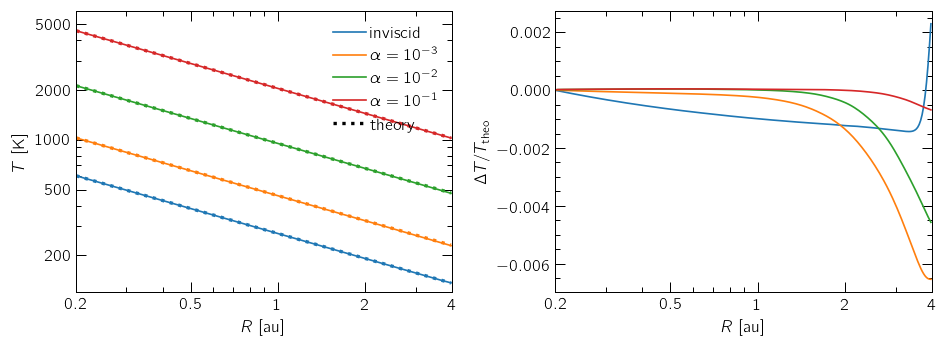

In [10]:
fig, ax = plt.subplots(ncols=2, figsize=(8,3), dpi=120)

r = grid.x1[grid.act1].to_value('au')

def fmt(x): return x[grid.active][0,-1].to_value('K')
ax[0].plot(r, fmt(Disk1.tmp), label='inviscid')
ax[0].plot(r, fmt(Disk2.tmp), label=r'$\alpha=10^{-3}$')
ax[0].plot(r, fmt(Disk3.tmp), label=r'$\alpha=10^{-2}$')
ax[0].plot(r, fmt(Disk4.tmp), label=r'$\alpha=10^{-1}$')

ax[0].set_yscale('log')
ax[0].set_ylim(120, 6000)
ax[0].set_yticks([200, 500, 1000, 2000, 5000])
ax[0].set_yticklabels([f'{s:g}' for s in ax[0].get_yticks()])
ax[0].set_ylabel(r'$T$ [K]')
ax[1].set_ylabel(r'$\Delta T/T_\mathrm{theo}$')

for axis in ax:
    axis.set_xscale('log')
    axis.set_xlim(0.2, 4)
    axis.set_xticks([0.2, 0.5, 1, 2, 4])
    axis.set_xticklabels([f'{s:g}' for s in axis.get_xticks()])
    axis.set_xlabel(r'$R$ [au]')

def T_theo_complex(alpha):
    GM, gamma = star.GM, Gas.gamma
    Rgas, mu, sigma = fld.tools.Rgas, Gas.mu, const.sigma_sb
    kappa = Dust.kappaP * d2g
    b = 9/16 * Rgas * alpha * np.sqrt(gamma) * np.sqrt(GM)/(mu*kappa*sigma) * u.au**-1.5 / u.K**3
    d = 1/4 * star.L / (4 * np.pi * u.au**2 * sigma * u.K**4) * np.exp(-0.1)
    b, d = b.to_value(''), d.to_value('')
    # this is now a polynomial of form x^4 - px - q = 0, with x = T/K, r=R/au, p = b / r^1.5, q = d / r^2
    p, q = b * r ** -1.5, d * r ** -2
    qplus  = p**2/2 + np.sqrt(p**4/4 + 64/27*q**3)
    qminus = p**2/2 - np.sqrt(p**4/4 + 64/27*q**3)
    z = np.sign(qplus) * np.abs(qplus) ** (1/3) + np.sign(qminus) * np.abs(qminus) ** (1/3)
    m = np.sqrt(z)
    with np.errstate(invalid='ignore'): # if inviscid, m -> 0: ignore b term, recover irradiation solution
        y = np.where(m<1e-15, q ** 0.25, 0.5 * (m + np.sqrt(-z + 2*p/m)))

    return y

ax[0].plot(r, T_theo_complex(0), ls=':', lw=2, c='C0')
ax[0].plot(r, T_theo_complex(1e-3), ls=':', lw=2, c='C1')
ax[0].plot(r, T_theo_complex(1e-2), ls=':', lw=2, c='C2')
ax[0].plot(r, T_theo_complex(1e-1), ls=':', lw=2, c='C3')

ax[1].plot(r, fmt(Disk1.tmp) / T_theo_complex(0) - 1, c='C0')
ax[1].plot(r, fmt(Disk2.tmp) / T_theo_complex(1e-3) - 1, c='C1')
ax[1].plot(r, fmt(Disk3.tmp) / T_theo_complex(1e-2) - 1, c='C2')
ax[1].plot(r, fmt(Disk4.tmp) / T_theo_complex(1e-1) - 1, c='C3')

ax[0].plot(np.nan, np.nan, c='k', ls=':', lw=2, label='theory')
ax[0].legend()

fig.tight_layout()

plt.show()